In [1]:
import pandas as pd
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
import os
import requests
from tqdm import tqdm
from sqlalchemy import create_engine
from statsmodels.tsa.statespace.sarimax import SARIMAX
from itertools import product
import platform
import statsmodels.api as sm
import ssl
import certifi
from urllib.request import urlopen
import json
from statsmodels.tools.sm_exceptions import ConvergenceWarning
from DATA.stock_invest_function import *
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.stats.diagnostic import acorr_ljungbox
from sklearn.metrics import mean_absolute_error
import warnings
warnings.filterwarnings("ignore")

matplotlib.rc('font', family='Malgun Gothic')
plt.rcParams['axes.unicode_minus'] = False

In [2]:
## 통상 데이터 수집

# DB 접속 정보 설정
db_info = {
    'user': 'stox7412',         # 예: 'root'
    'password': 'Apt106503!~', # 예: '1234'
    # 'host': '192.168.0.230',
    'host': 'hystox74.synology.me',         # 예: 'localhost' 또는 IP
    'port': '3307',              # 기본 포트는 보통 3306
    'database': 'investar'        # 예: 'trade_data'
}

In [14]:
fs_df = fetch_table_data(db_info, "korea_fs_data")
fs_df.rename(columns={'Date': 'date'}, inplace=True)
trade_df = fetch_table_data(db_info, "korea_monthly_trade_data")

✅ 'korea_fs_data' 테이블에서 5584577건의 데이터를 가져왔습니다.
✅ 'korea_monthly_trade_data' 테이블에서 579780건의 데이터를 가져왔습니다.


In [43]:
cosmetic_indus = trade_df[
    (trade_df['root_hs_code'].str.contains('330499')) &
    (trade_df['indicator'] == 'expDlr')
]

# 1. date 컬럼을 datetime 형식으로 변환
cosmetic_indus['date'] = pd.to_datetime(cosmetic_indus['date'])

# 2. 분기 기준으로 변환 (연-분기 문자열로)
cosmetic_indus['quarter'] = cosmetic_indus['date'].dt.to_period('Q')

# 3. 분기별 value 합산
quarterly_sum = cosmetic_indus.groupby('quarter')['value'].sum().reset_index()

# 4. YOY 변화율 계산 (1년 전 분기 대비)
quarterly_sum['trade_yoy_growth'] = quarterly_sum['value'].pct_change(periods=4)

In [47]:
cosmetic_indus.tail(13)

,date,root_hs_code,indicator,value,quarter
544176,2024-05-31,330499,expDlr,674157000.0,2024Q2
546951,2024-06-30,330499,expDlr,595925000.0,2024Q2
549721,2024-07-31,330499,expDlr,617618000.0,2024Q3
552486,2024-08-31,330499,expDlr,625319000.0,2024Q3
555251,2024-09-30,330499,expDlr,703105000.0,2024Q3
558021,2024-10-31,330499,expDlr,803009000.0,2024Q4
560781,2024-11-30,330499,expDlr,690422000.0,2024Q4
563556,2024-12-31,330499,expDlr,660166000.0,2024Q4
566326,2025-01-31,330499,expDlr,559906000.0,2025Q1
569096,2025-02-28,330499,expDlr,666463000.0,2025Q1


In [45]:
ticker = 'A257720'

target_fs = fs_df[(fs_df['symbol'] == ticker) & (fs_df['indicator'] == '매출액(천원)')].copy()
target_fs['date'] = pd.to_datetime(target_fs['date'])
target_fs['quarter'] = target_fs['date'].dt.to_period('Q')
target_fs_refine = target_fs[target_fs['value'] != 0]
target_fs_refine = target_fs_refine.iloc[1:]
target_fs_refine['fs_yoy_growth'] = target_fs_refine['value'].pct_change(periods=4).dropna(axis=0)

                            OLS Regression Results                            
Dep. Variable:          fs_yoy_growth   R-squared:                       0.468
Model:                            OLS   Adj. R-squared:                  0.419
Method:                 Least Squares   F-statistic:                     9.661
Date:                Tue, 24 Jun 2025   Prob (F-statistic):            0.00996
Time:                        14:31:36   Log-Likelihood:                -4.0561
No. Observations:                  13   AIC:                             12.11
Df Residuals:                      11   BIC:                             13.24
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                       coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------
const                0.7025      0.104  

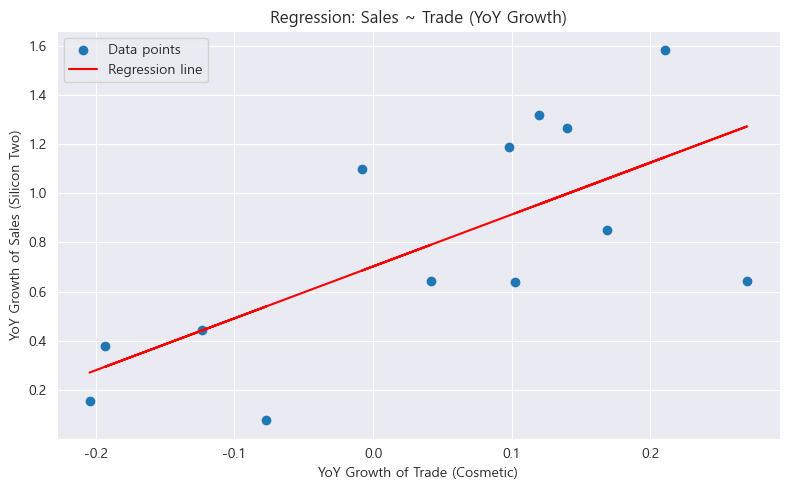

In [46]:
# 1. 필요한 DataFrame 복사 (이미 quarter 컬럼 있음)
df_trade = quarterly_sum[['quarter', 'trade_yoy_growth']].copy()
df_fs = target_fs_refine[['quarter', 'fs_yoy_growth']].copy()

# 2. NaN 제거 (fs_yoy_growth 기준)
df_fs = df_fs.dropna(subset=['fs_yoy_growth'])

# 3. quarter 기준으로 병합
reg_df = pd.merge(df_trade, df_fs, on='quarter', how='inner')

# 4. X, Y 설정
X = reg_df['trade_yoy_growth']
Y = reg_df['fs_yoy_growth']

# 5. 회귀 분석 (상수 추가)
X_const = sm.add_constant(X)
model = sm.OLS(Y, X_const).fit()

# 6. 결과 출력
print(model.summary())

# 7. 시각화 (산점도 + 회귀선)
plt.figure(figsize=(8, 5))
plt.scatter(X, Y, label='Data points')
plt.plot(X, model.predict(X_const), color='red', label='Regression line')
plt.xlabel('YoY Growth of Trade (Cosmetic)')
plt.ylabel('YoY Growth of Sales (Silicon Two)')
plt.title('Regression: Sales ~ Trade (YoY Growth)')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()